In [1]:


from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'OP', 'AD']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [5]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [6]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [7]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names = 'value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [8]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)



tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 自编码器降维路径 VAE_dimension_reduction_path
VAE_dimension_reduction_path = os.path.join(resample_axis_data_path, 'VAE_dimension_reduction')
os.listdir(VAE_dimension_reduction_path)

['SWT_imag_VAE_dimension_reduction',
 'SWT_magnitude_VAE_dimension_reduction',
 'SWT_phase_VAE_dimension_reduction',
 'SWT_real_VAE_dimension_reduction']

In [9]:
Specific_data_VAE_dimension_reduction_path = os.path.join(VAE_dimension_reduction_path, 'SWT_imag_VAE_dimension_reduction')
os.listdir(Specific_data_VAE_dimension_reduction_path)

['SWT_imag_latent_features.csv',
 'VAE_dimension_reduction_class.pkl',
 'VAE_dimension_reduction_params.pth']

In [16]:
Specific_data_latent_features_path = os.path.join(Specific_data_VAE_dimension_reduction_path, 'SWT_imag_latent_features.csv')
Specific_data_latent_features = pd.read_csv(Specific_data_latent_features_path)

latent_features = Specific_data_latent_features.dropna().values
latent_features[:5]

array([[-1.689382  ,  1.2626523 ,  0.02620593, -1.0891751 ,  0.7258497 ,
         0.34211633, -0.71977365, -1.5505416 ,  0.5242049 ,  1.954184  ,
        -2.3550434 ,  1.3681908 , -0.01956317, -0.38037732,  0.6217482 ,
        -0.08616076, -0.06933446, -1.410064  , -0.8563737 ],
       [ 0.7492204 ,  4.398903  ,  0.6340676 ,  0.14012338, -0.12889452,
         0.5378544 , -1.2488196 , -0.73742974,  0.62675357, -0.73924583,
         0.09524278,  1.4020935 , -0.1414343 , -0.5936433 , -1.5866051 ,
         0.23466542,  2.0972872 ,  0.93052447,  2.2544596 ],
       [-1.0781335 ,  0.02251674,  2.2334456 ,  0.3305149 ,  2.2114117 ,
        -1.0366043 , -1.4215158 ,  0.04477799,  1.8145348 , -0.31795314,
         0.9297975 , -1.1309953 ,  1.2180158 ,  0.02764153, -3.036531  ,
        -0.91632813,  1.1350454 , -1.0748966 , -0.6620932 ],
       [-0.4501962 , -1.1596812 , -0.0801127 ,  0.56518483, -0.68632746,
        -0.10023078, -0.64512545,  0.7168632 ,  0.19776726, -1.1578102 ,
         0.533

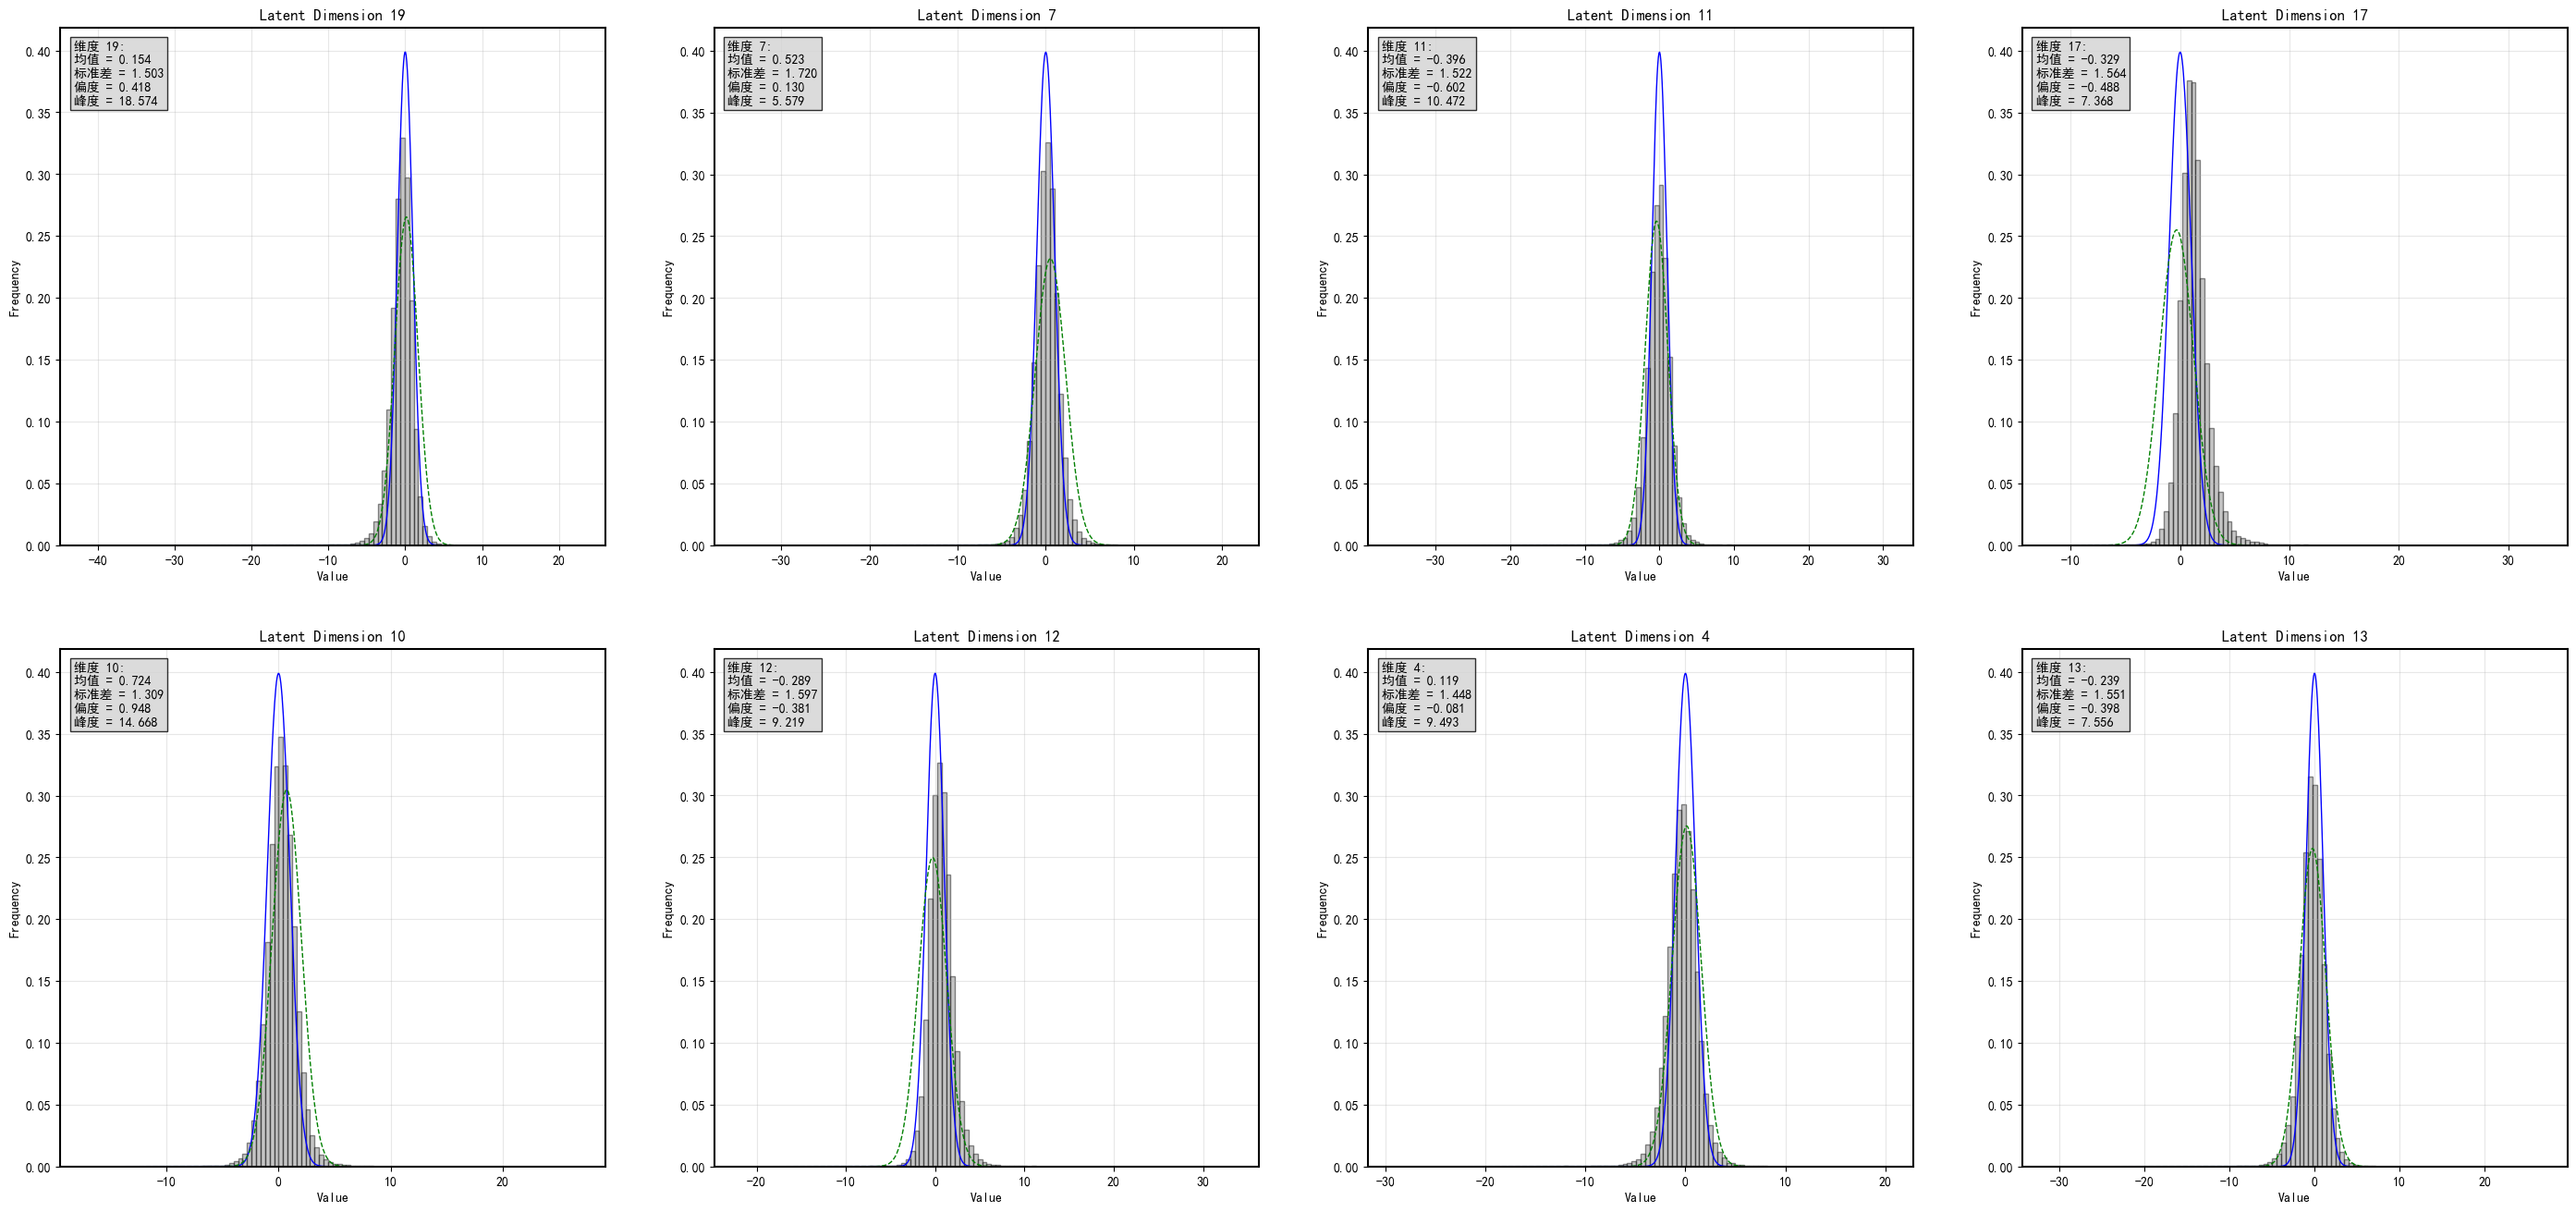

In [15]:
def plot_latent_histograms(latent_features):
    """
    绘制潜在特征随机维度的分布直方图及正态拟合
    """
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
    plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问

    fig, axes = plt.subplots(2, 4, figsize = (35, 16))
    axes = axes.flatten()

    import random
    random_column_list = random.sample(range(latent_features.shape[1]), 8)
    for i in range(min( 8, latent_features.shape[1] )):

        axes[i].hist(latent_features[:, random_column_list[i]], bins = 100, alpha = 0.45, density = True, color = 'gray', edgecolor = 'black')
        axes[i].set_title(f'Latent Dimension {random_column_list[i] + 1}')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].set_facecolor('none')
        axes[i].spines[:].set_visible(True)  # 显示所有边框
        axes[i].grid(True, alpha = 0.3)

        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)      # 增加线宽
            spine.set_color('black')    # 深灰色，确保可见
            spine.set_alpha(1)            # 完全不透明

        data = latent_features[:, i]
        mean_val = np.mean(data)
        std_val = np.std(data)

        x_min, x_max = axes[i].get_xlim()
        x = np.linspace(x_min, x_max, 800)  # 生成标准正态分布的x值范围

        from scipy import stats
        y_standard = stats.norm.pdf(x, 0, 1)  # 绘制标准正态分布（目标分布：N(0, 1))
        axes[i].plot(
            x, y_standard, 'blue', linewidth = 1, alpha = 1,  label = '标准正态 N(0,1)'
        )

        y_fitted = stats.norm.pdf(x, mean_val, std_val)   # 绘制实际数据的正态拟合
        axes[i].plot(
            x, y_fitted, 'g--', linewidth = 1, alpha = 1, label = f'拟合正态 N({mean_val:.2f},{std_val:.2f})'
        )

        stats_text = f'维度 {random_column_list[i] + 1}:\n'
        stats_text += f'均值 = {mean_val:.3f}\n'
        stats_text += f'标准差 = {std_val:.3f}\n'
        stats_text += f'偏度 = {stats.skew(data):.3f}\n'
        stats_text += f'峰度 = {stats.kurtosis(data):.3f}'
        axes[i].text(  # 添加统计信息文本框
            0.025, 0.975, stats_text, transform = axes[i].transAxes,
            fontsize = 10, verticalalignment = 'top',
            bbox = dict(boxstyle = 'square', alpha = 0.8, facecolor = 'lightgray')
        )

    plt.show()

plot_latent_histograms(latent_features)

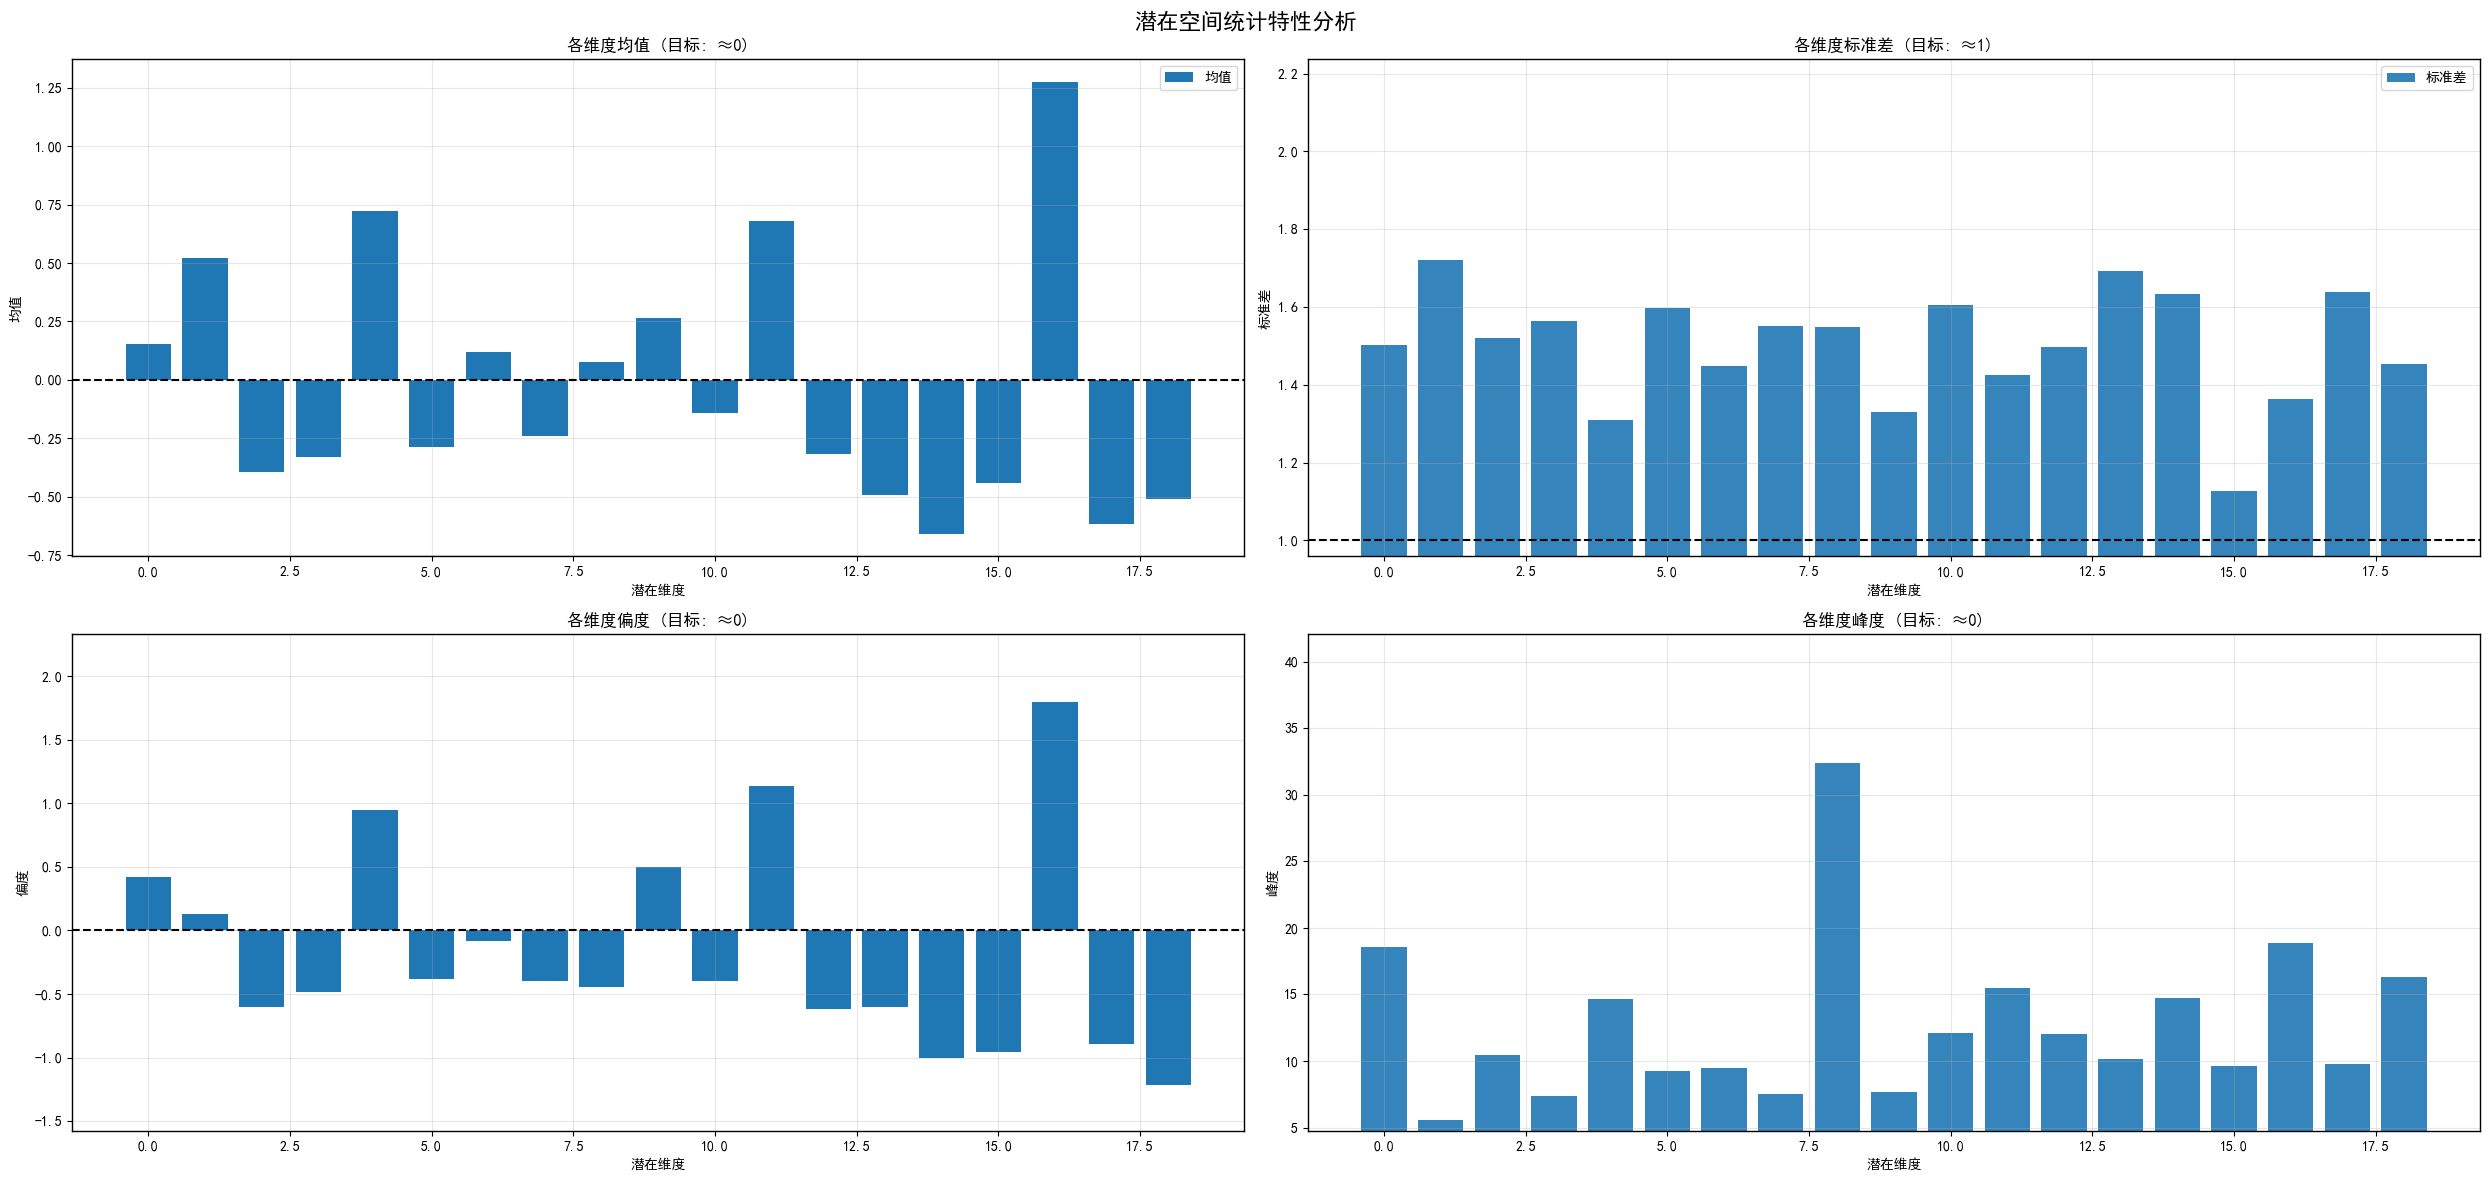

均值范围: [-0.659, 1.274]
标准差范围: [1.128, 1.720]
与标准正态的相似度:
  • 均值接近0的比例: 1/19 (5.3%)
  • 标准差接近1的比例: 1/19 (5.3%)


In [19]:
def plot_latent_statistics(latent_features):
    """
    绘制潜在特征各维度的统计特性（均值、标准差、偏度、峰度）
    """
    from scipy import stats

    n_samples, latent_dim = latent_features.shape
    means = np.mean(latent_features, axis = 0)   # 计算每个维度的统计量
    stds = np.std(latent_features, axis = 0)
    skews = stats.skew(latent_features, axis = 0)
    kurtosis = stats.kurtosis(latent_features, axis = 0)


    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
    plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问

    fig, axes = plt.subplots(2, 2, figsize = (25, 12))

    # 均值和标准差
    axes[0, 0].bar(range(latent_dim), means, color = '#1f77b4', label = '均值')
    axes[0, 0].axhline(y = 0, color = 'black', linestyle = '--')
    axes[0, 0].set_title('各维度均值 (目标: ≈0)')
    axes[0, 0].set_xlabel('潜在维度')
    axes[0, 0].set_ylabel('均值')
    # axes[0, 0].set_ylim(min( means ) * 1.3, max( means ) * 1.3)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha = 0.3)
    axes[0, 0].set_facecolor('none')
    for spine in axes[0, 0].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
        spine.set_alpha(1)   # 完全不透明

    axes[0, 1].bar(range(latent_dim), stds, color = '#1f77b4', alpha = 0.9, label = '标准差')
    axes[0, 1].axhline(y = 1, color = 'black', linestyle = '--')
    axes[0, 1].set_title('各维度标准差 (目标: ≈1)')
    axes[0, 1].set_xlabel('潜在维度')
    axes[0, 1].set_ylabel('标准差')
    axes[0, 1].set_ylim(min( stds ) * 0.85, max( stds ) * 1.3)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha = 0.3)
    axes[0, 1].set_facecolor('none')
    for spine in axes[0, 1].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
        spine.set_alpha(1)   # 完全不透明

    # 偏度和峰度
    axes[1, 0].bar(range(latent_dim), skews, color = '#1f77b4')
    axes[1, 0].axhline(y = 0, color = 'black', linestyle = '--')
    axes[1, 0].set_title('各维度偏度 (目标: ≈0)')
    axes[1, 0].set_xlabel('潜在维度')
    axes[1, 0].set_ylabel('偏度')
    axes[1, 0].set_ylim(min( skews ) * 1.3, max( skews ) * 1.3)
    axes[1, 0].grid(True, alpha = 0.3)
    axes[1, 0].set_facecolor('none')
    for spine in axes[1, 0].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
        spine.set_alpha(1)   # 完全不透明

    axes[1, 1].bar(range(latent_dim), kurtosis, color = '#1f77b4', alpha = 0.9)
    axes[1, 1].axhline(y = 0, color = 'black', linestyle = '--')
    axes[1, 1].set_title('各维度峰度 (目标: ≈0)')
    axes[1, 1].set_xlabel('潜在维度')
    axes[1, 1].set_ylabel('峰度')
    axes[1, 1].set_ylim(min( kurtosis ) * 0.85, max( kurtosis ) * 1.3)
    axes[1, 1].grid(True, alpha = 0.3)
    axes[1, 1].set_facecolor('none')
    for spine in axes[1, 1].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
        spine.set_alpha(1)   # 完全不透明

    plt.suptitle('潜在空间统计特性分析', fontsize = 16, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    # 打印统计摘要
    print(f"均值范围: [{means.min():.3f}, {means.max():.3f}]")
    print(f"标准差范围: [{stds.min():.3f}, {stds.max():.3f}]")
    print(f"与标准正态的相似度:")
    print(f"  • 均值接近0的比例: {(np.abs(means) < 0.1).sum()}/{latent_dim} ({(np.abs(means) < 0.1).sum() / latent_dim * 100:.1f}%)")
    print(f"  • 标准差接近1的比例: {(np.abs(stds - 1) < 0.2).sum()}/{latent_dim} ({(np.abs(stds - 1) < 0.2).sum() / latent_dim * 100:.1f}%)")

plot_latent_statistics(latent_features)

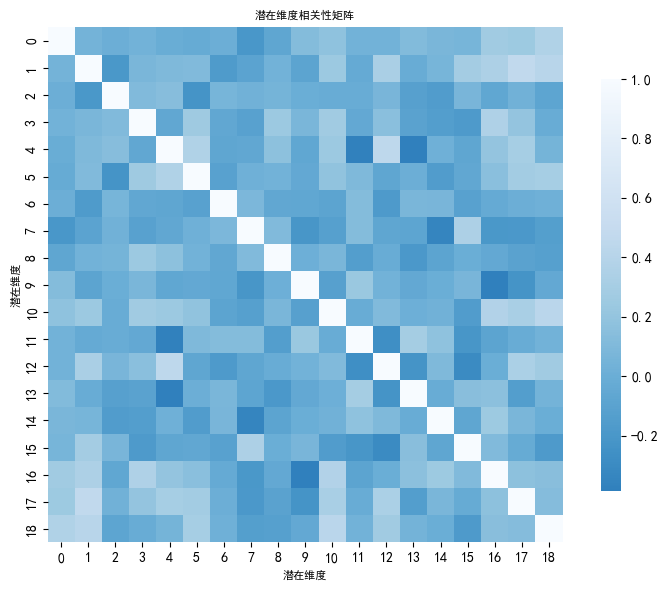

平均绝对相关性: 0.1347
强相关维度比例 (|r| > 0.3): 20/171 (11.7%)


In [20]:
def plot_latent_correlation(latent_features):
    """
    绘制潜在特征维度间的相关性热力图
    """
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
    plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问
    plt.figure(figsize = (8, 6), dpi = 100)

    corr_matrix = np.corrcoef(latent_features, rowvar = False)  # 计算相关系数矩阵
    sns.heatmap(
        corr_matrix,
        cmap = 'Blues_r', center = 0,  # Greys 灰色渐变, RdBu 红蓝渐变, Blues 蓝白渐变, _r 尾缀表色带倒置
        square = True, cbar_kws = {"shrink": 0.8}
    )

    plt.title('潜在维度相关性矩阵', fontsize = 8, fontweight = 'bold')
    plt.xlabel('潜在维度', fontsize = 8)
    plt.ylabel('潜在维度', fontsize = 8)
    plt.tight_layout()
    plt.show()

    # 计算平均绝对相关性
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    upper_tri = corr_matrix[mask]
    avg_corr = np.mean(np.abs(upper_tri))

    print(f"平均绝对相关性: {avg_corr:.4f}")
    print(f"强相关维度比例 (|r| > 0.3): {(np.abs(upper_tri) > 0.3).sum()}/{len(upper_tri)} ({(np.abs(upper_tri) > 0.3).sum()/len(upper_tri)*100:.1f}%)")

plot_latent_correlation(latent_features)

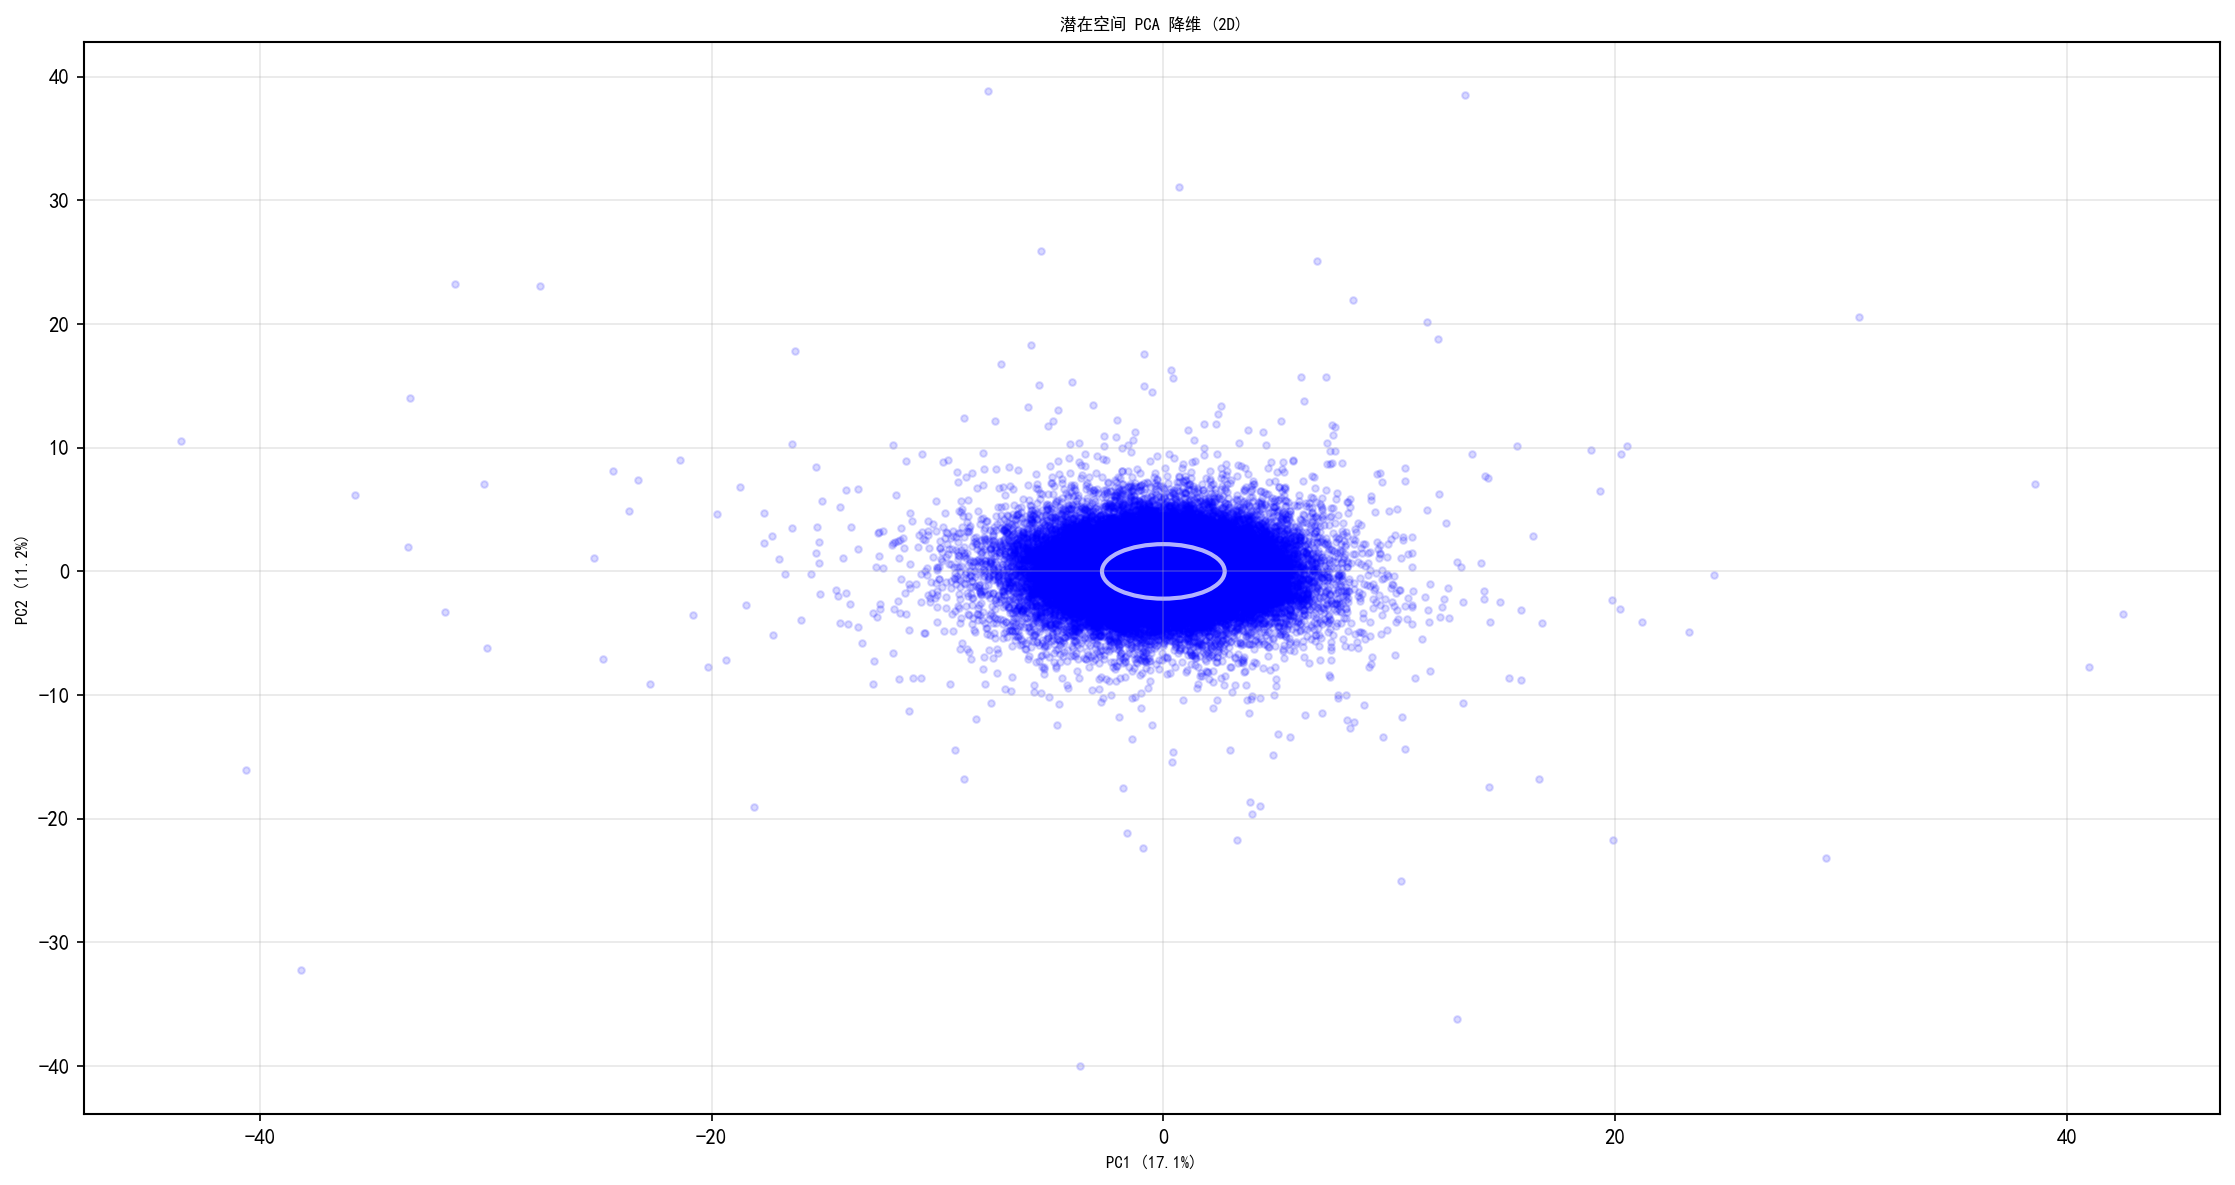

In [21]:
def plot_latent_pca(latent_features):
    """
    绘制潜在特征PCA降维后的2D散点图
    """

    from sklearn.decomposition import PCA
    pca = PCA(n_components = 2)  # 初始化 PCA 模型到 n_components 个维度
    latent_pca = pca.fit_transform(latent_features)  # 使用 PCA 降维到 2D

    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
    plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问
    fig, ax = plt.subplots(figsize = (15, 8), dpi = 150)
    ax.scatter(
        latent_pca[:, 0],
        latent_pca[:, 1],
        alpha = 0.15, s = 10, c = 'blue'
    )

    ax.set_title('潜在空间 PCA 降维 (2D)', fontsize = 8)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize = 8)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize = 8)
    ax.grid(True, alpha = 0.3)
    ax.set_facecolor('none')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color('black')
        spine.set_alpha(1)   # 完全不透明


    from matplotlib.patches import Ellipse
    ellipse = Ellipse(   # 添加椭圆表示分布
        xy = (
            np.mean(latent_pca[:, 0]),
            np.mean(latent_pca[:, 1])
        ),
        width = np.std(latent_pca[:, 0]) * 2,
        height = np.std(latent_pca[:, 1]) * 2,
        edgecolor = 'white', fc = 'None', lw = 2, alpha = 0.7
    )
    ax.add_patch(ellipse)
    plt.tight_layout()
    plt.show()

plot_latent_pca(latent_features)